საფინანსო სექტორის რისკების მენეჯერი და საკრედიტო შეფასების
სისტემა (CreditRisk Analytics)

პრობლემის იდეა: აპლიკაცია აანალიზებს მსესხებლების ფინანსურ და პერსონალურ
პროფილს და გასცემს რეკომენდაციას კლიენტის საკრედიტო სანდოობის შესახებ.

საკვლევი თემა: კლასთა დისბალანსის მართვა, ნორმალიზაცია და
გადაწყვეტილების ეთიკურად ახსნადი (explainable) წარმოდგენა.

მონაცემთა ბაზა: Credit Risk Dataset (Kaggle)

In [4]:
import pandas as pd
data = pd.read_csv("credit_risk_dataset.csv")
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
data.shape

(32581, 12)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [ ]:
მონაცემთა ზომა: ბაზა შეიცავს 32581ს ჩანაწერს და 12 სვეტს-features
რიცხვითი ცვლადები 
person_age (int64) - მსესხებლის ასაკი.
person_income (int64) - მსესხებლის წლიური შემოსავალი.
person_emp_length (float64) - სამუშაო სტაჟი წლებში.
loan_amnt (int64) - მოთხოვნილი სესხის ოდენობა.
loan_int_rate (float64) - სესხის საპროცენტო განაკვეთი.
loan_percent_income (float64) - სესხის წილი წლიურ შემოსავალთან მიმართებაში.
cb_person_cred_hist_length (int64) - საკრედიტო ისტორიის ხანგრძლივობა წლებში.

კატეგორიული ცვლადები 
person_home_ownership (object) - საცხოვრებელი ფართის საკუთრების სტატუსი (მაგ: RENT, OWN, MORTGAGE).
loan_intent (object) - სესხის აღების მიზანი (მაგ: PERSONAL, EDUCATION, MEDICAL).
loan_grade (object) - სესხის რეიტინგი / კლასი.
cb_person_default_on_file (object) - საკრედიტო ბიუროს ისტორიაში დეფოლტის არსებობა (Y/N).


loan_status (int64) - სამიზნე რიცხვითი ცვლადი (დეფოლტის სტატუსი: 0 ან 1).

In [8]:
print("\n--- Missing Values ---")
miss = data.isnull().sum()
miss_pct = (miss / len(data) * 100).round(2)
miss_report = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
miss_report = miss_report[miss_report["missing_count"] > 0].sort_values("missing_count", ascending=False)
print(miss_report)


--- Missing Values ---
                   missing_count  missing_pct
loan_int_rate               3116         9.56
person_emp_length            895         2.75


In [9]:
# 1. person_emp_length-ის შევსება მედიანით
data['person_emp_length'] = data['person_emp_length'].fillna(data['person_emp_length'].median())

# 2. loan_int_rate-ის შევსება მედიანით
data['loan_int_rate'] = data['loan_int_rate'].fillna(data['loan_int_rate'].median())

person_emp_length: 895 გამოტოვებული მნიშვნელობა (მთლიანი მონაცემების დაახლოებით 2.75%).
loan_int_rate: 3,116 გამოტოვებული მნიშვნელობა (მთლიანი მონაცემების დაახლოებით 9.56%).
გამოტოვებული მნიშვნელობები შევავსეთ მედიანით რადგან აუთლაიერების მიმართ მგრძნობიარე არაა

In [10]:
print(data.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [11]:
print("\n" + "=" * 60)
print("1. სტატისტიკური ამოვარდნილები (IQR მეთოდით)")
print("=" * 60)
print("აღწერა: მნიშვნელობები, რომლებიც ძლიერ ცდება ნორმალურ განაწილებას (სცდება Q1 - 3*IQR და Q3 + 3*IQR საზღვრებს).\n")

numeric_cols = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length"
]

for col in numeric_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr
    
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"სვეტი: {col}")
    print(f"  - ზღვრები: ქვედა < {lower:.2f} ან ზედა > {upper:.2f}")
    print(f"  - ამოვარდნილების რაოდენობა: {len(outliers)}")
    print("-" * 50)

print("2. ფინანსური და ფიზიკური ბიზნეს-შეზღუდვები (Business Logic Outliers)")
print("=" * 60)

# არასრულწლოვანები (< 18)
invalid_age = data[data["person_age"] < 18]
print(f"\n[person_age < 18] - რაოდენობა: {len(invalid_age)}")
print("აღწერა: არასრულწლოვანი კანონით სესხს ვერ აიღებს.")

# უარყოფითი ან ნულოვანი შემოსავალი (<= 0)
invalid_income = data[data["person_income"] <= 0]
print(f"\n[person_income <= 0] - რაოდენობა: {len(invalid_income)}")
print("აღწერა: შემოსავალი უარყოფითი ან ნულოვანი ვერ იქნება.")

# უარყოფითი სამუშაო სტაჟი (< 0)
invalid_emp = data[data["person_emp_length"] < 0]
print(f"\n[person_emp_length < 0] - რაოდენობა: {len(invalid_emp)}")
print("აღწერა: სამუშაო სტაჟი უარყოფითი წლებში ვერ იქნება.")

# უარყოფითი სესხის ოდენობა (<= 0)
invalid_loan = data[data["loan_amnt"] <= 0]
print(f"\n[loan_amnt <= 0] - რაოდენობა: {len(invalid_loan)}")
print("აღწერა: სესხის თანხა უარყოფითი ან ნულოვანი ვერ იქნება.")

# უარყოფითი სესხის პროცენტი შემოსავლიდან (< 0)
invalid_pct = data[data["loan_percent_income"] < 0]
print(f"\n[loan_percent_income < 0] - რაოდენობა: {len(invalid_pct)}")
print("აღწერა: სესხის პროცენტი შემოსავალთან მიმართებაში უარყოფითი ვერ იქნება.")

# უარყოფითი საკრედიტო ისტორია (< 0)
invalid_hist = data[data["cb_person_cred_hist_length"] < 0]
print(f"\n[cb_person_cred_hist_length < 0] - რაოდენობა: {len(invalid_hist)}")
print("აღწერა: საკრედიტო ისტორიის ხანგრძლივობა უარყოფითი ვერ იქნება.")

print("=" * 60)
print("3. ლოგიკური ამოვარდნილი მნიშვნელობები (Domain-Knowledge Outliers)")
print("=" * 60)

# ასაკი > 100
age_outliers = data[data["person_age"] > 100]
print(f"\n[person_age > 100] - რაოდენობა: {len(age_outliers)}")
print("აღწერა: ადამიანის ასაკი 100 წელზე მეტია, რაც მონაცემთა შეყვანის შეცდომაა.")
print("მნიშვნელობები:")
print(age_outliers[["person_age", "person_income", "person_emp_length", "loan_status"]])

# სამუშაო სტაჟი > ასაკი
emp_age_outliers = data[data["person_emp_length"] > data["person_age"]]
print(f"\n[person_emp_length > person_age] - რაოდენობა: {len(emp_age_outliers)}")
print("აღწერა: სამუშაო სტაჟი ფიზიკურად აღემატება ადამიანის ასაკს.")
print("მნიშვნელობები:")
print(emp_age_outliers[["person_age", "person_emp_length", "loan_status"]])
print("\n" + "=" * 60)



1. სტატისტიკური ამოვარდნილები (IQR მეთოდით)
აღწერა: მნიშვნელობები, რომლებიც ძლიერ ცდება ნორმალურ განაწილებას (სცდება Q1 - 3*IQR და Q3 + 3*IQR საზღვრებს).

სვეტი: person_age
  - ზღვრები: ქვედა < 2.00 ან ზედა > 51.00
  - ამოვარდნილების რაოდენობა: 249
--------------------------------------------------
სვეტი: person_income
  - ზღვრები: ქვედა < -83600.00 ან ზედა > 201300.00
  - ამოვარდნილების რაოდენობა: 433
--------------------------------------------------
სვეტი: person_emp_length
  - ზღვრები: ქვედა < -13.00 ან ზედა > 22.00
  - ამოვარდნილების რაოდენობა: 54
--------------------------------------------------
სვეტი: loan_amnt
  - ზღვრები: ქვედა < -16600.00 ან ზედა > 33800.00
  - ამოვარდნილების რაოდენობა: 192
--------------------------------------------------
სვეტი: loan_int_rate
  - ზღვრები: ქვედა < -5.37 ან ზედა > 26.97
  - ამოვარდნილების რაოდენობა: 0
--------------------------------------------------
სვეტი: loan_percent_income
  - ზღვრები: ქვედა < -0.33 ან ზედა > 0.65
  - ამოვარდნილების რა

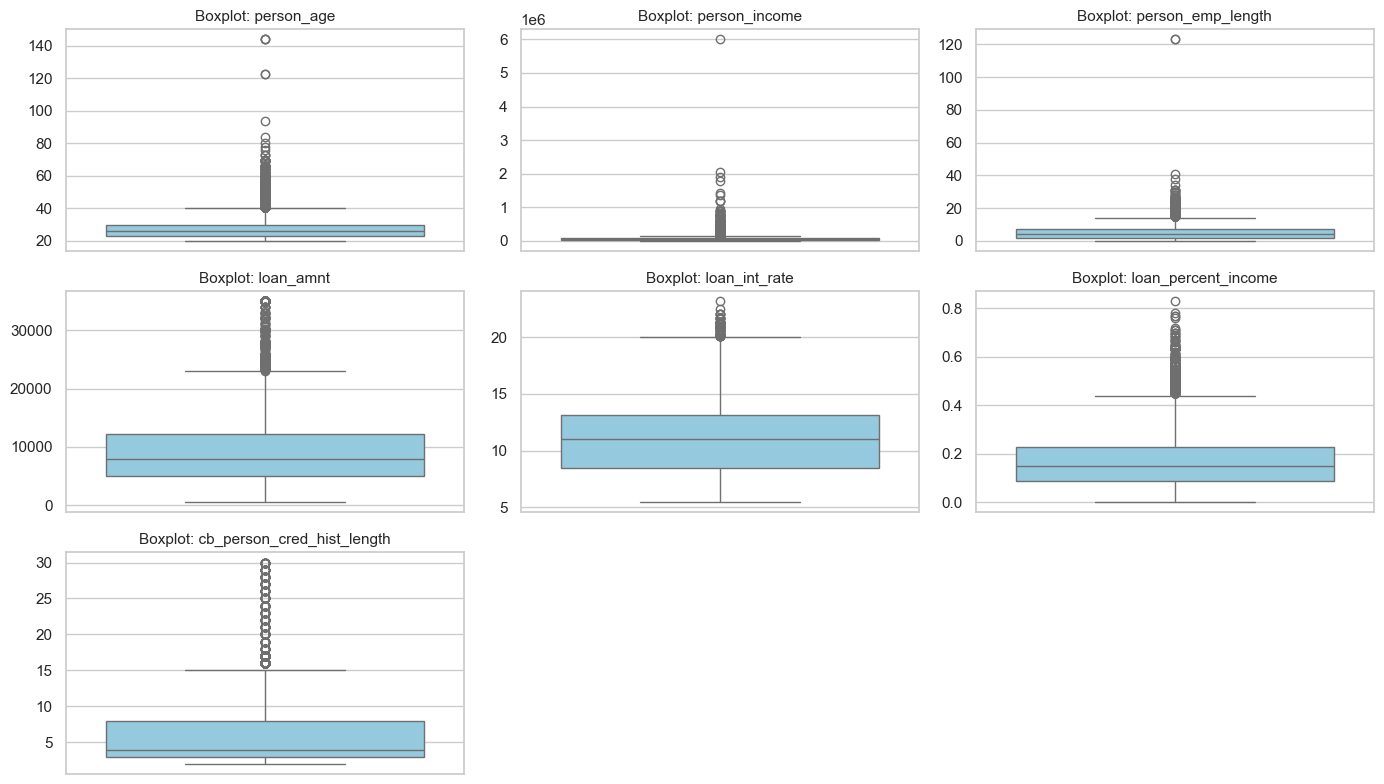

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")


for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col], color="skyblue")
    plt.title(f"Boxplot: {col}", fontsize=11)
    plt.ylabel("")

plt.tight_layout()
plt.show()

IQR მეთოდმა უბრალოდ დააფიქსირა უკიდურესი ექსტრემალური ციფრები, რომელთა წაშლაც მონაცემებიდან საჭირო არ არის, რადგან ისინი რეალურ კლიენტებს წარმოადგენენ.
აბსურდული მონაცემები: 7 ჩანაწერი (ასაკი 100 წელზე მეტია ან სამუშაო სტაჟი ასაკს აღემატება). ამათი ამოშლა სავალდებულოა, რადგან ტექნიკური შეცდომებია. 

In [13]:
# 1. ასაკი 100 წელზე მეტია
data = data[data["person_age"] <= 100]

# 2. სამუშაო სტაჟი აღემატება ადამიანის ასაკს
data = data[data["person_emp_length"] <= data["person_age"]]

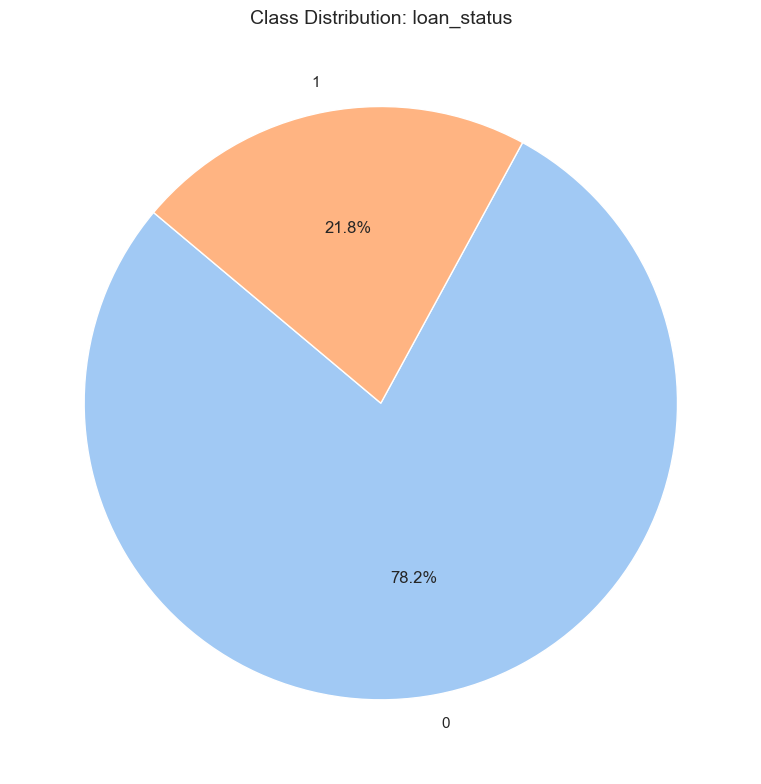

In [13]:
target_col = "loan_status"

class_counts = data[target_col].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel")
)

plt.title(f"Class Distribution: {target_col}", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()

სახეზეა მონაცემთა დისბალანსი, სადაც დაკვირვებების უმეტესი ნაწილი (78.2%) კლასი 0-ია, ხოლო უმცირესობა (21.8%) — კლასი 1.
დისბალანსის აღმოსაფხვრელად გამოვიყენეთ, SMOTE, რომელიც  ქმნის ხელოვნურ მაგალითებს იშვიათი კლასისთვის,რათა მონაცემები გათანაბრდეს და ტრენინგი ზუსტი იყოს.

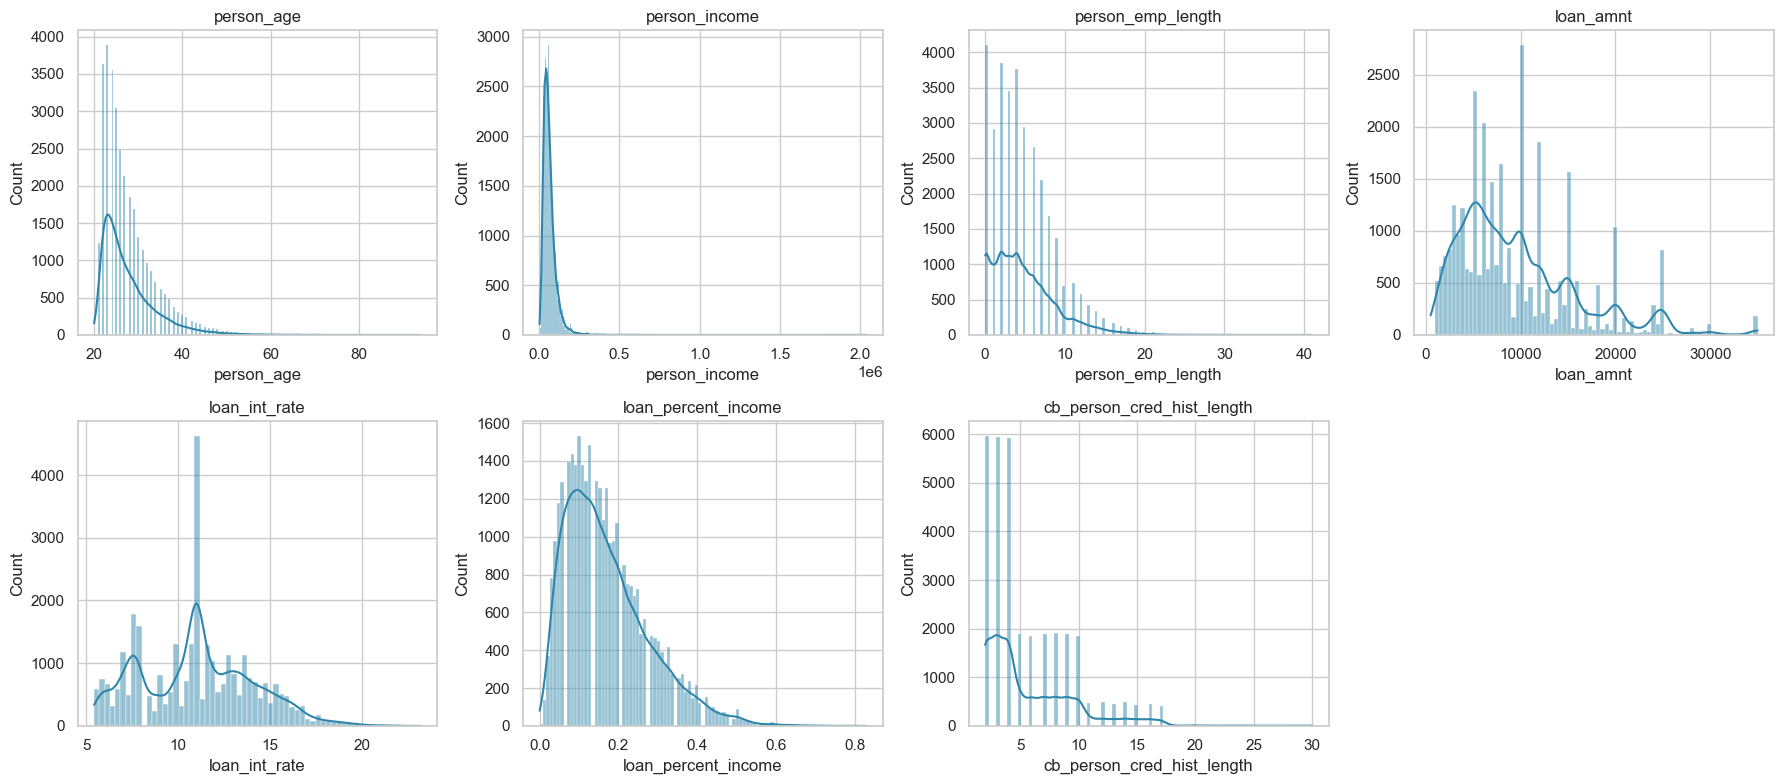

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols ):
    sns.histplot(data[col].dropna(), kde=True, ax=axes_flat[i], color="#2E86AB")
    axes_flat[i].set_title(col)

if len(numeric_cols ) < len(axes_flat):
    fig.delaxes(axes_flat[-1])

plt.tight_layout()
plt.show()

ასაკი-განაწილება მარჯვნივ არის გადახრილი,კლიენტების უმრავლესობა ახალგაზრდაა (ძირითადად 20-დან 30 წლამდე),ხოლო ასაკის მატებასთან ერთად სიხშირე მკვეთრად მცირდება.
შემოსავალი-მონაცემთა აბსოლუტური უმრავლესობა თავმოყრილია დაბალ და საშუალო შემოსავლებზე, ხოლო რამდენიმე უკიდურესი ექსტრემალური წერტილი (მილიონიანი შემოსავლები)
სამუშაო სტაჟი-ასევე მარჯვნივ გადახრილი განაწილება.მომხმარებელთა უმეტესობას მუშაობის მცირე სტაჟი აქვს (0-დან 5 წლამდე
სესხის ოდენოაბ- ახასიათებს მრავალმწვერვალიანი განაწილება,სადაც პიკები გარკვეულ სტანდარტულ თანხებზე ფიქსირდება (მაგ. 5000, 10000, 15000). მაქსიმალური ზღვარი ძირითადად 35000-ია.
საპროცენტო განაკვეთი-ძირითადი მასა ნაწილდება 7%-დან 13%-მდე ინტერვალში.
სესხის წილი შემოსავალთან-უმეტეს შემთხვევაში სესხის თანხა შეადგენს წლიური შემოსავლის 10%-დან 30%-მდე ნაწილს.

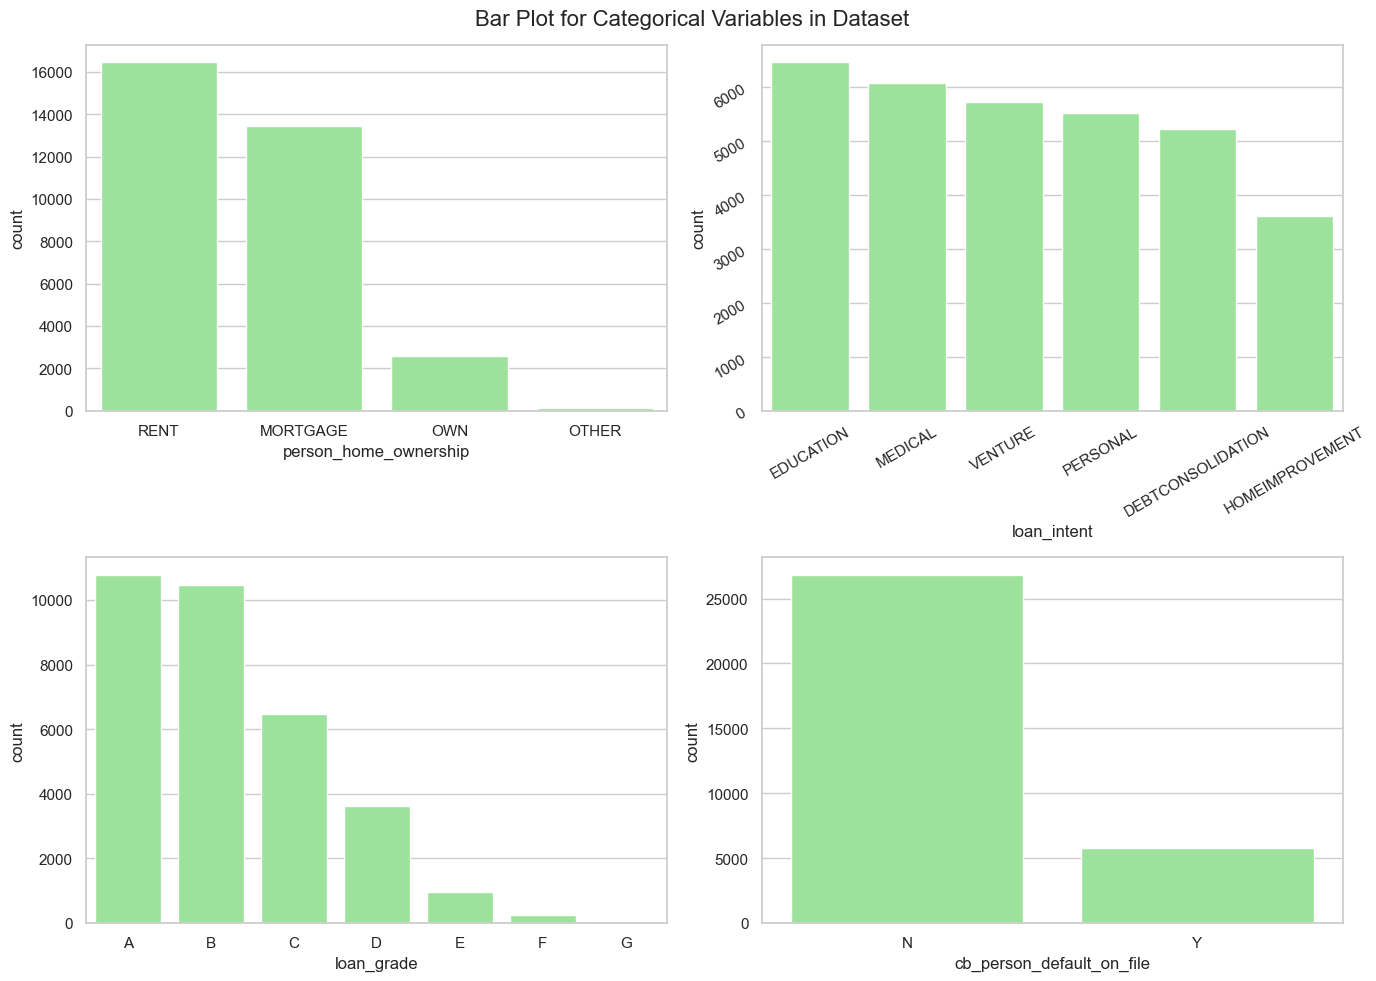

In [15]:
# მხოლოდ არსებული კატეგორიული სვეტები
CATEGORICAL_FEATURES = [
    'person_home_ownership', 
    'loan_intent', 
    'loan_grade', 
    'cb_person_default_on_file'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bar Plot for Categorical Variables in Dataset', fontsize=16)

sns.countplot(ax=axes[0, 0], x=data['person_home_ownership'], color='lightgreen', order=data['person_home_ownership'].value_counts().index)
sns.countplot(ax=axes[0, 1], x=data['loan_intent'], color='lightgreen', order=data['loan_intent'].value_counts().index)
sns.countplot(ax=axes[1, 0], x=data['loan_grade'], color='lightgreen', order=data['loan_grade'].value_counts().index)
sns.countplot(ax=axes[1, 1], x=data['cb_person_default_on_file'], color='lightgreen', order=data['cb_person_default_on_file'].value_counts().index)

axes[0][0].tick_params(labelrotation=0)
axes[0][1].tick_params(labelrotation=30)
axes[1][0].tick_params(labelrotation=0)
axes[1][1].tick_params(labelrotation=0)

plt.tight_layout()
plt.show()

საცხოვრებლის საკუთრების ფორმა-ბაზაში კლიენტების აბსოლუტური უმრავლესობა ან ქირაობს ბინას (16000 კლიენტი) ან აქვს იპოთეკა (~13000 კლიენტი),
საკუთარი სახლი ჰყავს მცირე ნაწილს.
სესხის აღების მიზანი-სესხის მიზნები საკმაოდ თანაბადაა განაწილებული, თუმცა ლიდერობს განათლება და სამედიცინო ხარჯები.
სესხის კლასი-რაოდენობრივად ძირითადად ხარისხიანი სესხები ჭარბობს: ყველაზე მეტი რაოდენობით წარმოდგენილია A და B კლასის სესხები,კლასების მატებასთან ერთად (C-დან G-სკენ) სესხების რაოდენობა მკვეთრად მცირდება და ყველაზე მინიმალური რაოდენობა G კლას აქვს.შესაბამისად, სანდო და დაბალი რისკის მქონე კლიენტები აშკარად ჭარბობენ რისკიან და პრობლემურ კლიენტებზე.
წარსულში დეფოლტის ისტორია ბიუროში-კლიენტების დიდი უმრავლესობას წარსულში დეფოლტის ისტორია არ ჰქონია.

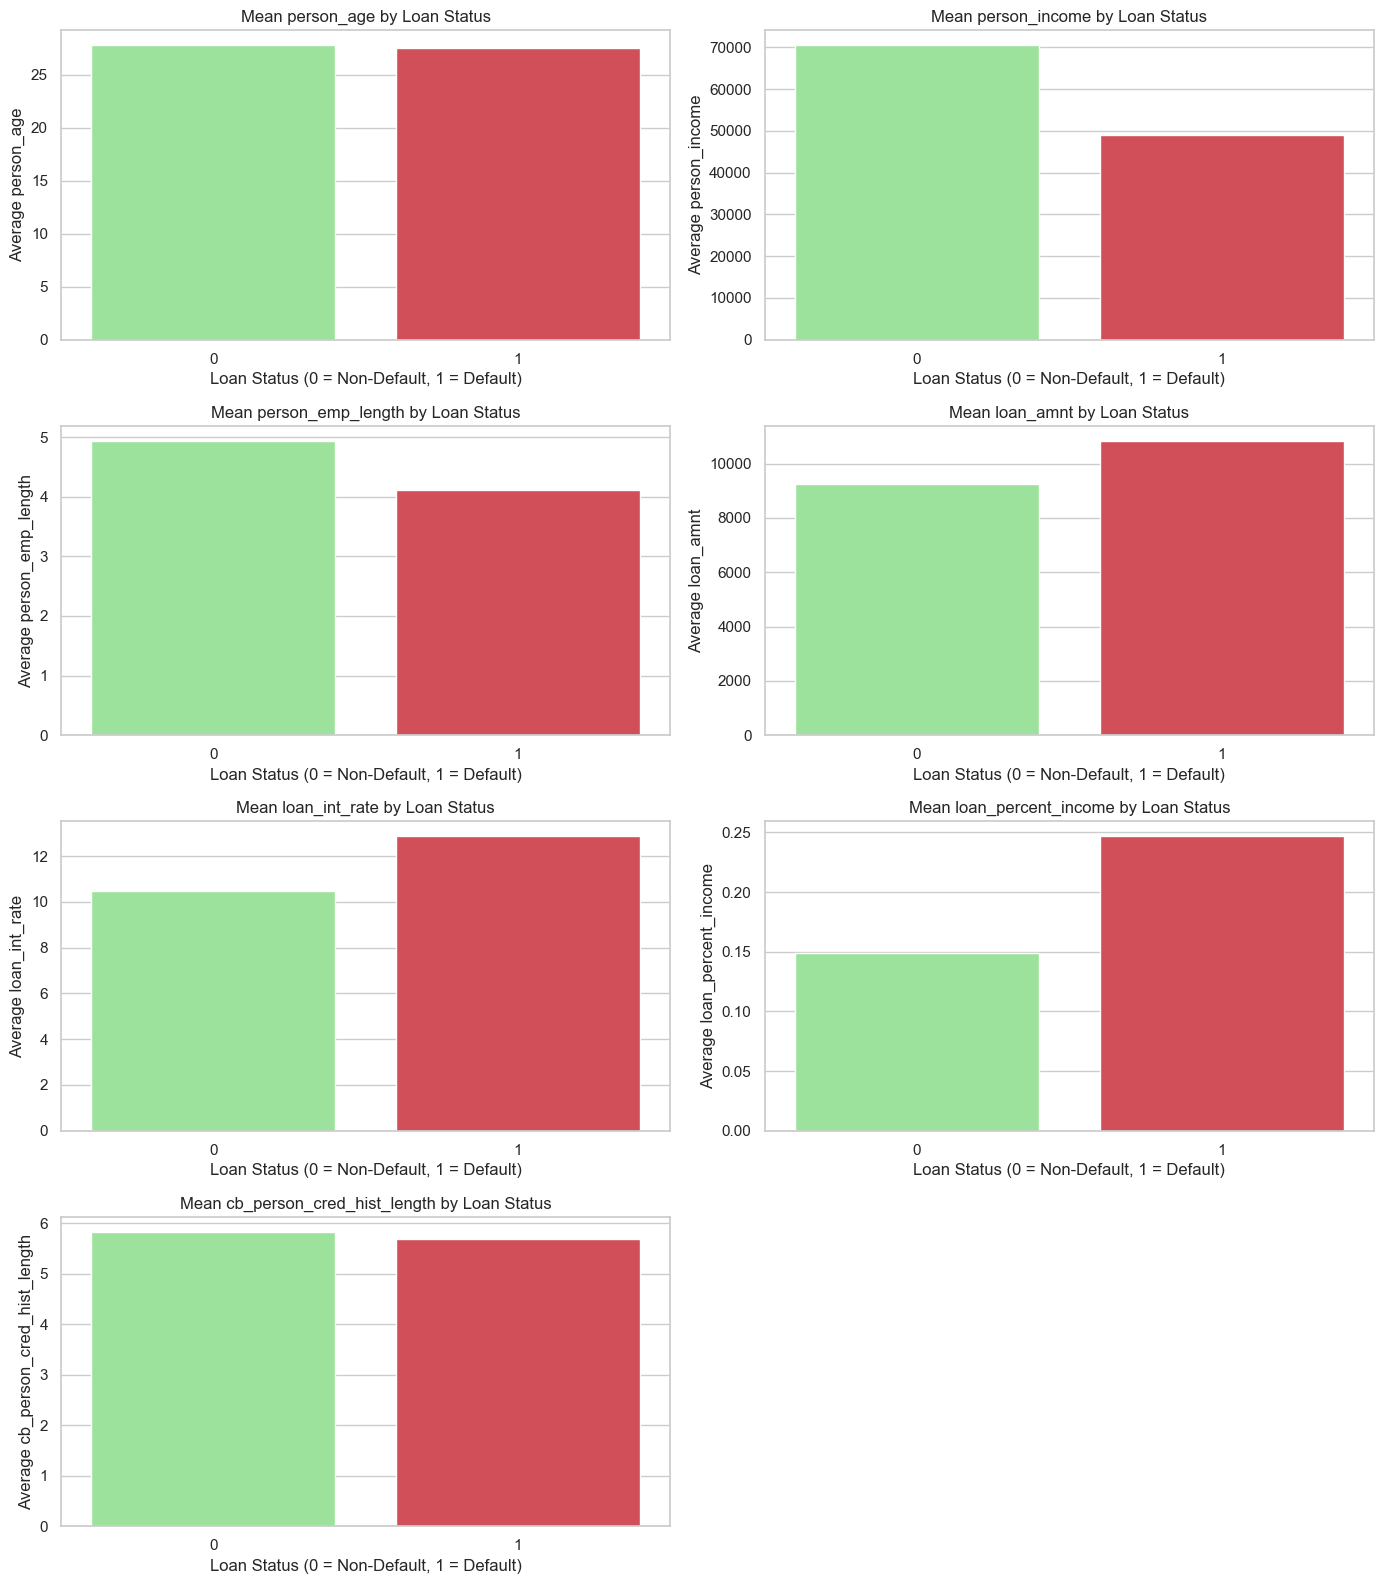

In [16]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    mean_vals = data.groupby('loan_status')[col].mean().reset_index()
    
    sns.barplot(
        x='loan_status', 
        y=col, 
        data=mean_vals, 
        ax=ax, 
        hue='loan_status', 
        palette=["lightgreen", "#E63946"], 
        legend=False
    )
    
    ax.set_title(f"Mean {col} by Loan Status")
    ax.set_xlabel("Loan Status (0 = Non-Default, 1 = Default)")
    ax.set_ylabel(f"Average {col}")


for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

შემოსავალი-არადეფოლტირებულებს შესამჩნევად მაღალი საშუალო შემოსავალი აქვთ (70000), ვიდრე დეფოლტისტებს (48000–50000).დაბალი შემოსავალი რისკს მკვეთრად ზრდის.
სესხის წილი შემოსავლიდან-დეფოლტირებულ ჯგუფში ეს მაჩვენებელი ორჯერ მეტია ჯანსაღ სესხებთან შედარებით,რაც წარმოდგენს გადახდის უუნარობის  განმსაზღვრელ ფაქტორს.
სესხის ოდენობა  დეფოლტირებულ სესხებზე აღებული თანხის საშუალო ოდენობა ოდნავ მეტია, ვიდრე ჯანსაღ სესხებზე, რაც, დაბალ შემოსავალთან ერთად, გადახდის პრობლემებს ზრდის.
საპროცენტო განაკვეთი რისკიან მსესხებლებს უფრო მაღალი პროცენტი აქვთ (13%), ვიდრე წარმატებულებს (10.5%).
ასაკი და სტაჟი: ამ პარამეტრების მიხედვით განსხვავება მინიმალურია და დეფოლტზე პირდაპირ გავლენას არ ახდენს.

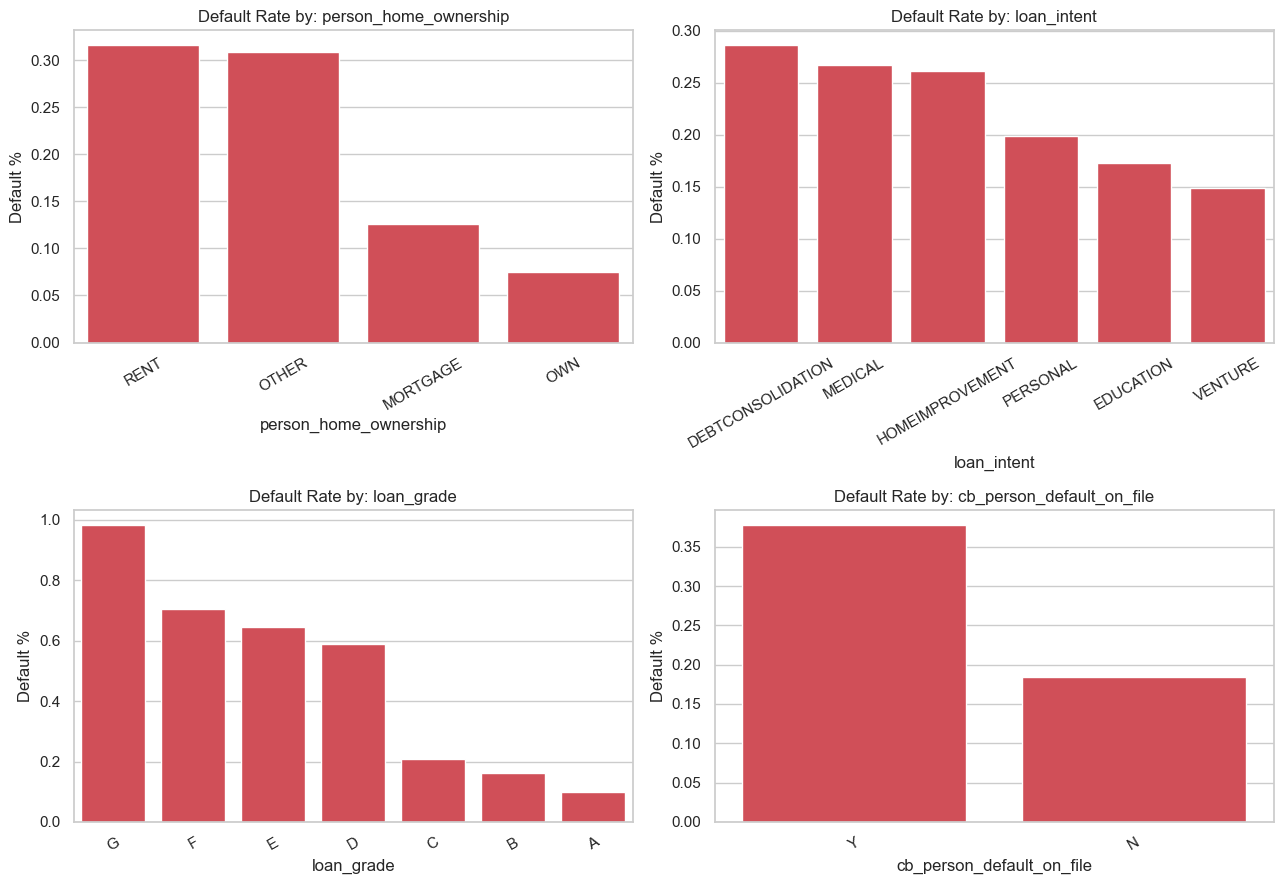

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), CATEGORICAL_FEATURES):
    rates = data.groupby(col)["loan_status"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.index, y=rates.values, ax=ax, color="#E63946")
    ax.set_title(f"Default Rate by: {col}")
    ax.set_ylabel("Default %")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

საცხოვრებლის საკუთრების ფორმა-ყველაზე მაღალი დეფოლტის რისკი აქვთ იმ კლიენტებს,რომლებიც ქირაობენ ბინას  ან აქვთ სხვა კატეგორია (OTHER).ყველაზე დაბალი რისკი ფიქსირდება მაშინ, როდესაც კლიენტი არის საკუთარი სახლის მესაკუთრე (OWN) ან აქვს იპოთეკა (MORTGAGE).
სესხის აღების მიზანი-დეფოლტის ყველაზე მაღალი მაჩვენებელი აქვს ვალების კონსოლიდაციასა და სამედიცინო ხარჯებზე  აღებულ სესხებს.
სესხის კლასი-საკრედიტო რეიტინგის გაუარესებასთან ერთად (A კლასიდან G კლასის მიმართულებით) დეფოლტის ალბათობა პროგრესულად მატულობს.
წარსულში დეფოლტის ისტორია-იმ პირებს,რომლებსაც წარსულში უკვე ჰქონდათ ფიქსირებული დეფოლტი,ახალი სესხის გადაუხდელობის რისკი აქვთ თითქმის 37%.
იმ კლიენტებთან შედარებით, რომლებსაც მსგავსი ისტორია არ აქვთ (18%), რისკი ორჯერ მეტია,რაც ამ ცვლადს მოდელისთვის ერთ-ერთ უმნიშვნელოვანეს ფაქტორად აქცევს.

In [14]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    FunctionTransformer
)

RANDOM_STATE = 42


X = data.drop(columns=["loan_status"]) 
y = data["loan_status"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 4. Feature Engineering ფუნქცია
def feature_engineering(data):
    data = data.copy()
    data["interest_income"] = data["loan_int_rate"] * data["loan_percent_income"]
    return data

numeric_features = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length", "interest_income"
]
ordinal_features = ["loan_grade"]
binary_features = ["cb_person_default_on_file"]
nominal_features = ["person_home_ownership", "loan_intent"]


numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("grade", OrdinalEncoder(categories=[["A","B","C","D","E","F","G"]],
                            handle_unknown="use_encoded_value", unknown_value=-1), ordinal_features),
    ("binary", OrdinalEncoder(categories=[["N","Y"]],
                            handle_unknown="use_encoded_value", unknown_value=-1), binary_features),
    ("nominal", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_features),
])


def build_pipeline(classifier):
    return ImbPipeline([
        ("fe", FunctionTransformer(feature_engineering, validate=False)),
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", classifier),
    ])


შევქმენით Feature Engineering -  interest_income -  აერთიანებს ორ უმნიშვნელოვანეს რისკ-ფაქტორს — საპროცენტო განაკვეთს და სესხის წილს შემოსავალთან.
აფიქსირებს მსესხებლის რეალურ ფინანსურ წნეხს.თუ ადამიანს ძვირიანი სესხი აქვს და თან შემოსავლის დიდ ნაწილს ხარჯავს მის დასაფარად,ეს ნამრავლი იძლევა მაღალ ციფრს (რისკის ზონას).
მოდელს (განსაკუთრებით ხეებზე დაფუძნებულ ალგორითმებს) უმარტივებს რისკიანი მომხმარებლების გამოყოფას.

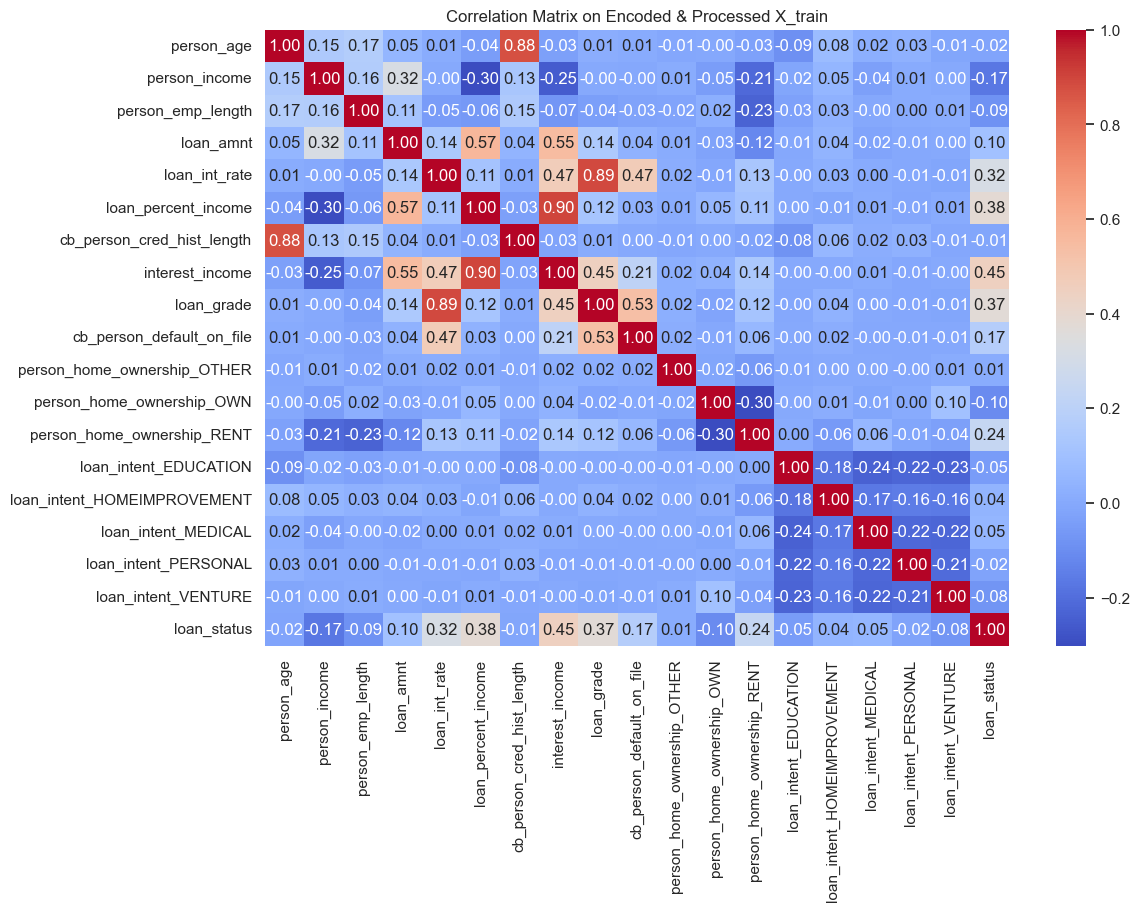

In [15]:
corr_pipeline = Pipeline([
    ("fe", FunctionTransformer(feature_engineering, validate=False)),
    ("preprocessor", preprocessor)
])


X_train_encoded_array = corr_pipeline.fit_transform(X_train)


ohe_feature_names = corr_pipeline.named_steps["preprocessor"].named_transformers_["nominal"].get_feature_names_out(nominal_features)
all_feature_names = numeric_features + ordinal_features + binary_features + list(ohe_feature_names)


X_train_encoded_df = pd.DataFrame(X_train_encoded_array, columns=all_feature_names)
X_train_encoded_df['loan_status'] = y_train.values

plt.figure(figsize=(12, 8))
correlation_matrix = X_train_encoded_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix on Encoded & Processed X_train")
plt.show()

1. მაღალი დადებითი კოლერაციები
person_age და cb_person_cred_hist_length შორის ძალიან მაღალი დადებითი კორელაციაა, რაც ლოგიკურია, რაც უფრო ასაკოვანია ადამიანი, მით უფრო დიდი საკრედიტო ისტორიის ხანგრძლივობა აქვს მას.
interest_income და loan_percent_income  ძლიერი კავშირია,რადგან ახალი შექმნილი ცვლადი პირდაპირ ითვლება პროცენტული შემოსავლისა და სავალუტო განაკვეთის ნამრავლით.
loan_int_rate და loan_grade შორის არის ძალიან მაღალი კორელაცია (0.89),რაც სავსებით მოსალოდნელია, რადგან საკრედიტო რეიტინგი (Grade A-დან G-მდე) პირდაპირ განსაზღვრავს სესხის საპროცენტო განაკვეთს.

2. უარყოფითი  კორელაციები
person_income და loan_percent_income-  რაც უფრო მაღალია ადამიანის შემოსავალი, მით უფრო მცირე პროცენტს შეადგენს სესხი მის წლიურ შემოსავალში.
სახლის საკუთრება- მსუბუქი უარყოფითი კავშირია, რაც მიუთითებს, რომ ქირაში მცხოვრებ პირებს საშუალოდ ოდნავ დაბალი შემოსავალი აქვთ, ვიდრე საკუთარი სახლის მფლობელებს.

3.თარგეთთან კოლერაცია 
ყველაზე მაღალი კოლერაცია აქვს ჩვენს მიერ შექმნილ ფიჩერს - interest_income  რაც ადასტურებს,რომ შემოსავალთან შედარებით მაღალი საპროცენტო ტვირთი დეფოლტის მთავარი მამოძრავებელია.
ლoan_percent_income (0.38) და loan_grade (0.37)აჩვენებს,რომ რაც უფრო მაღალია სესხის წილი შემოსავლიდან და რაც უფრო უარესია კლასი მით უფრო იზრდება რისკი.
person_income მაღალი შემოსავალი პოზიტიურად მოქმედებს და ამცირებს დეფოლტის შანსს.
person_home_ownership_OWN (-0.10) და person_emp_length (-0.09)-საკუთარი სახლის არსებობა და სამუშაო სტაჟი სტაბილურობის და დაბალი რისკის მანიშნებელია.


In [29]:
X_train_encoded_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,interest_income,loan_grade,cb_person_default_on_file,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,1.189340,1.304607,-0.441667,0.861277,1.861606,-0.565214,0.302363,-0.051214,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.214482,0.641886,0.314536,0.464512,-0.011414,-0.378296,1.046158,-0.348118,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.760376,-0.626306,-0.693735,-1.122548,1.508389,-0.939049,-0.441433,-0.584428,4.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-0.922852,0.179050,0.314536,-0.090959,-1.259014,-0.471755,-0.937296,-0.756289,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,3.951438,1.886792,1.070739,2.448336,0.999628,-0.191379,6.004795,0.142773,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import RandomizedSearchCV
#  კროს-ვალიდაცია
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_spaces = {
    "LogisticRegression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"classifier__C": [0.01, 0.1, 1, 10, 100]}
    ),
    "DecisionTree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {
            "classifier__max_depth": [3, 5, 8, 12, None],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
        }
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "classifier__n_estimators": [200, 400, 600],
            "classifier__max_depth": [6, 10, 16, None],
            "classifier__min_samples_leaf": [1, 2, 4],
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            "classifier__n_estimators": [100, 200, 400],
            "classifier__max_depth": [3, 5, 7],
            "classifier__learning_rate": [0.01, 0.05, 0.1],
        }
    ),
}


results = {}
for name, (clf, grid) in search_spaces.items():
    pipe = build_pipeline(clf)
    search = RandomizedSearchCV(
        pipe, grid, n_iter=8, scoring="f1",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1,
        error_score='raise'
    )
    search.fit(X_train, y_train) 
    results[name] = search.best_estimator_
    print(f"{name}: best F1(CV)={search.best_score_:.4f}, params={search.best_params_}")

C:\Users\user\miniconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=8. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


LogisticRegression: best F1(CV)=0.6216, params={'classifier__C': 0.01}
DecisionTree: best F1(CV)=0.7928, params={'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 8}
RandomForest: best F1(CV)=0.8183, params={'classifier__n_estimators': 400, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
GradientBoosting: best F1(CV)=0.8344, params={'classifier__n_estimators': 400, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05}


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
train_results = {}
test_results = {}

for name, model in results.items():
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_train)
    
    train_results[name] = {
        "Train_Accuracy": accuracy_score(y_train, y_train_pred),
        "Train_Precision": precision_score(y_train, y_train_pred),
        "Train_Recall": recall_score(y_train, y_train_pred),
        "Train_F1": f1_score(y_train, y_train_pred),
        "Train_ROC-AUC": roc_auc_score(y_train, y_train_prob)
    }
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    test_results[name] = {
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_Precision": precision_score(y_test, y_test_pred),
        "Test_Recall": recall_score(y_test, y_test_pred),
        "Test_F1": f1_score(y_test, y_test_pred),
        "Test_ROC-AUC": roc_auc_score(y_test, y_test_prob)
    }

df_train = pd.DataFrame(train_results).T
df_test = pd.DataFrame(test_results).T
all_metrics_df = pd.concat([df_train, df_test], axis=1).round(4)

column_order = [
    "Train_Accuracy", "Test_Accuracy", 
    "Train_Precision", "Test_Precision", 
    "Train_Recall", "Test_Recall", 
    "Train_F1", "Test_F1", 
    "Train_ROC-AUC", "Test_ROC-AUC"
]
all_metrics_df = all_metrics_df[column_order]
all_metrics_df

,Train_Accuracy,Test_Accuracy,Train_Precision,Test_Precision,Train_Recall,Test_Recall,Train_F1,Test_F1,Train_ROC-AUC,Test_ROC-AUC
LogisticRegression,0.7911,0.7931,0.5139,0.5175,0.7865,0.7586,0.6216,0.6153,0.8677,0.8584
DecisionTree,0.9266,0.9226,0.9233,0.9281,0.7239,0.6995,0.8115,0.7978,0.9210,0.9032
RandomForest,0.9893,0.9285,0.9951,0.9377,0.9555,0.7199,0.9749,0.8145,0.9999,0.9272
GradientBoosting,0.9610,0.9332,0.9937,0.9633,0.8268,0.7213,0.9026,0.8249,0.9934,0.9469


საუკეთესო მოდელი არის GradientBoosting-მაქსიმალური F1-score (Test_F1=0.8249)მას აქვს ყველაზე მაღალი ჰარმონიული საშუალო precision da recall შორის ტესტურ მონაცემებზე.
საუკეთესო ROC-AUC (Test_ROC-AUC = 0.9469) yველაზე მაღალი მაჩვენებელი იმისა,თუ რამდენად კარგად განასხვავებს მოდელი კლასებს ერთმანეთისგან.
მაღალი სიზუსტე (Test_Precision = 0.9633) როდესაც ამბობს,რომ სესხი პრობლემურია, თითქმის არ ცდება.

მიუხედავად იმისა, რომ RandomForest-იც ძალიან ახლოსაა მასთან  GradientBoosting მაინც ჯობნის თითქმის ყველა ძირითადი მეტრიკით.

C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\user\miniconda3\Lib\site-packages\sklearn\utils\_plotting.p

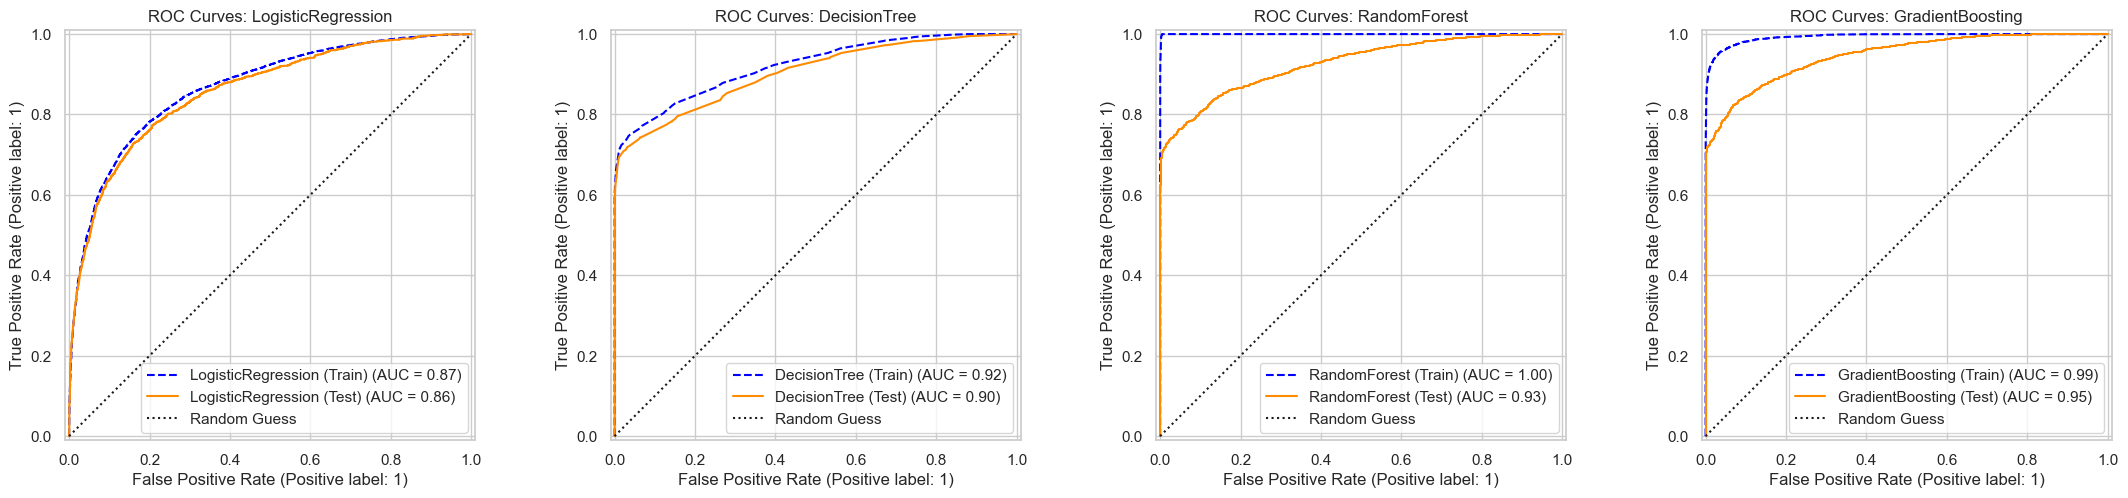

In [46]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, results.items()):
    
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
    else:
        y_train_prob = model.decision_function(X_train)
        
    RocCurveDisplay.from_predictions(
        y_train, y_train_prob, 
        name=f"{name} (Train)", 
        ax=ax, 
        color="blue", 
        linestyle="--"
    )
  
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_test_prob = model.decision_function(X_test)
        
    RocCurveDisplay.from_predictions(
        y_test, y_test_prob, 
        name=f"{name} (Test)", 
        ax=ax, 
        color="darkorange", 
        linestyle="-"
    )
    
    ax.set_title(f"ROC Curves: {name}", fontsize=12)
    ax.plot([0, 1], [0, 1], "k:", label="Random Guess")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

Gradient Boosting აფიქსირებს საუკეთესო პროგნოზირების უნარს სატესტო მონაცემებზე (AUC = 0.95), ხოლო Random Forest-ს აქვს გადამეტებული სწავლა,რადგან ტრენინგზე 100%-იანი სიზუსტე აქვს, ტესტზე კი მცირდება.

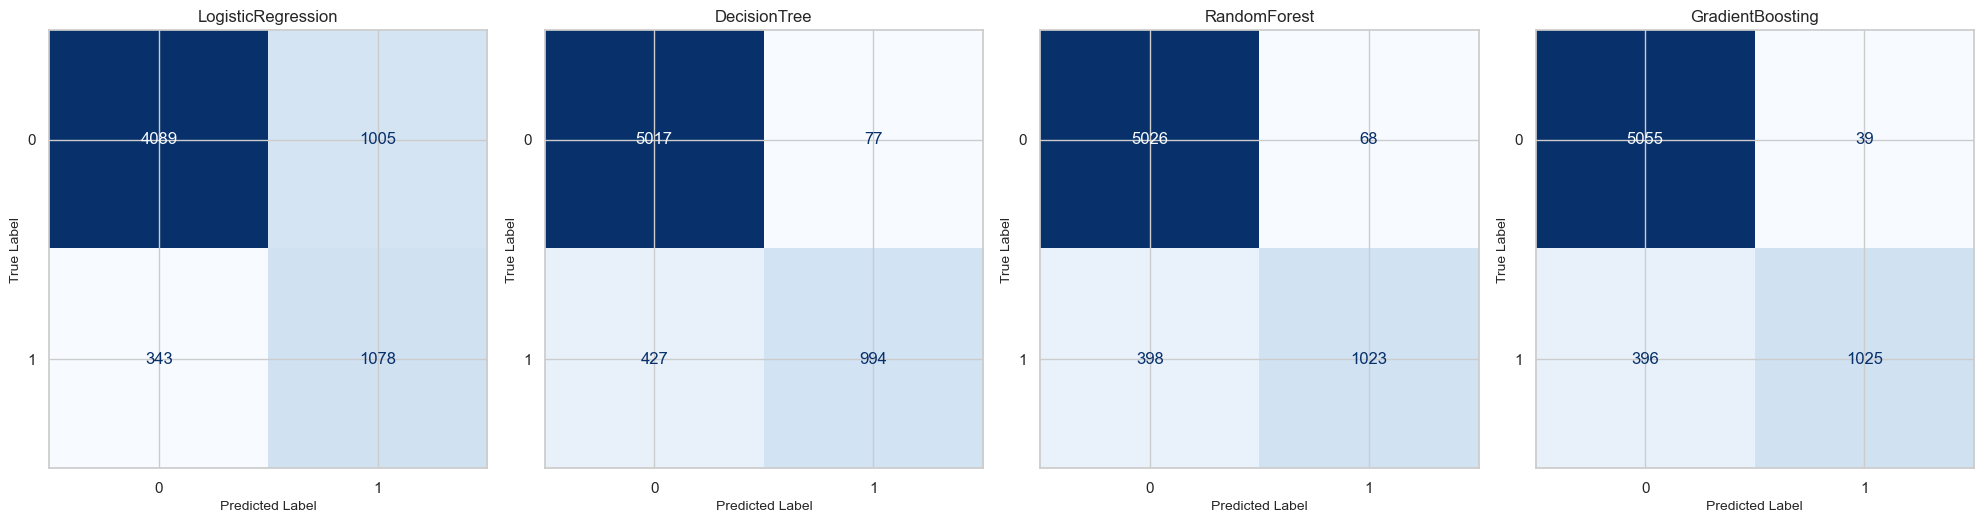

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 

axes = axes.flatten()

for ax, (name, model) in zip(axes, results.items()):
   
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    
    ax.set_title(f"{name}", fontsize=12)
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.show()

Gradient Boosting 
აქვს ყველაზე მეტი სწორი პროგნოზი  5055 (True Negative)კარგად პატიოსან კლიენტებს და 1025 (True Positive) კარგად ცნობს რეალურ დეფაულტს.
აქვს მინიმალური შეცდომები მხოლოდ 39  (False Positive) და 396 (False Negative)დეფოლტიანები პატიოსნად ჩათვალა


In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

clf = GradientBoostingClassifier(
    n_estimators=400, 
    max_depth=7, 
    learning_rate=0.05, 
    random_state=RANDOM_STATE
)

best_model = build_pipeline(clf)


best_model.fit(X_train, y_train)


y_probs = best_model.predict_proba(X_test)[:, 1]


custom_threshold = 0.3  


y_pred_new = (y_probs >= custom_threshold).astype(int)


print(f"Confusion Matrix (ახალი Threshold = {custom_threshold}):")
print(confusion_matrix(y_test, y_pred_new))

print(f"\nClassification Report (ახალი Threshold = {custom_threshold}):")
print(classification_report(y_test, y_pred_new))

Confusion Matrix (ახალი Threshold = 0.3):
[[4907  187]
 [ 329 1092]]

Classification Report (ახალი Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5094
           1       0.85      0.77      0.81      1421

    accuracy                           0.92      6515
   macro avg       0.90      0.87      0.88      6515
weighted avg       0.92      0.92      0.92      6515



67-ით მეტი ნამდვილი დეფოლტი დავიჭირეთ და ბანკი ზარალისგან გადავარჩინეთ,თუმცა მოდელი უფრო ეჭვიანი გახდა რამდენიმე პატიოსან კლიენტსაც უსამართლოდ უთხრა უარი. ჩემი აზრით ეს უკეთესია რადგან დეფოლტი ნაკლები გაგვეპარა და ზარალიც ნაკლები იქნბეა.

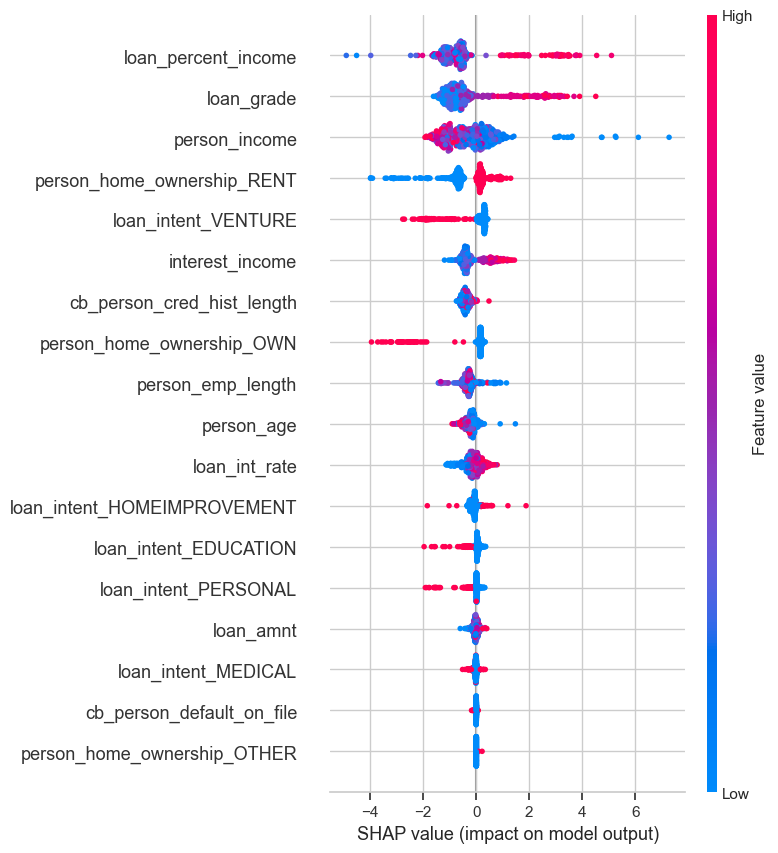

In [28]:
import shap

clf = best_model.named_steps["classifier"]
prep = best_model.named_steps["preprocessor"]

X_test_fe = feature_engineering(X_test)
X_test_transformed = prep.transform(X_test_fe)

feat_names = (numeric_features + ordinal_features + binary_features +
              list(prep.named_transformers_["nominal"].get_feature_names_out(nominal_features)))

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_transformed[:500])

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_transformed[:500], feature_names=feat_names)

ყველაზე გავლენიანი ფაქტორები
მოდელისთვის ყველაზე დიდ როლს ასრულებს loan_percent_income (სესხის წილი შემოსავალთან), loan_grade (სესხის კლასი) და person_income (წლიური შემოსავალი).

loan_percent_income (სესხის წილი შემოსავალთან)- რაც უფრო დიდია სესხის წილი შემოსავალთან, მით უფრო ზრდის მოდელი დეფოლტის რისკს.

loan_grade (სესხის კლასი)- ცუდი საკრედიტო კლასები მკვეთრად ზრდის სესხის გადაუხდელობის ალბათობას.

person_income (შემოსავალი) დაბალი შემოსავლის მქონე პირებს მეტი რისკი აქვთ, ხოლო მაღალი შემოსავალი  ამცირებს დეფოლტის ალბათობას.

ქირა ზრდის დეფოლტის რისკს,ხოლო საკუთარი სახლი  ამცირებს რისკს 

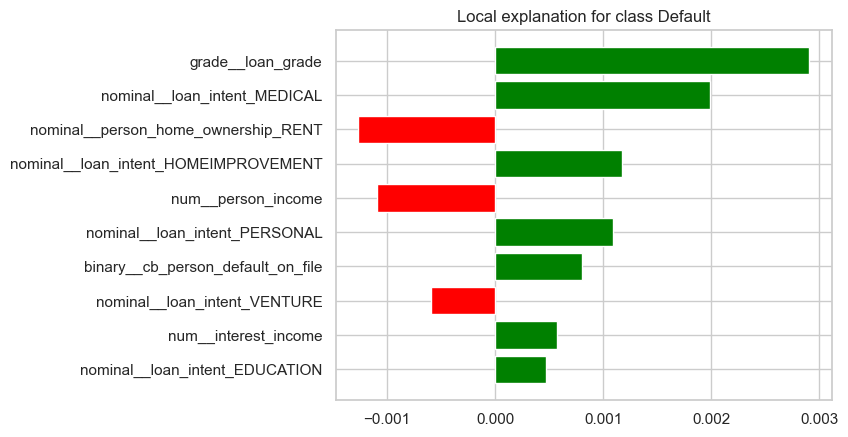

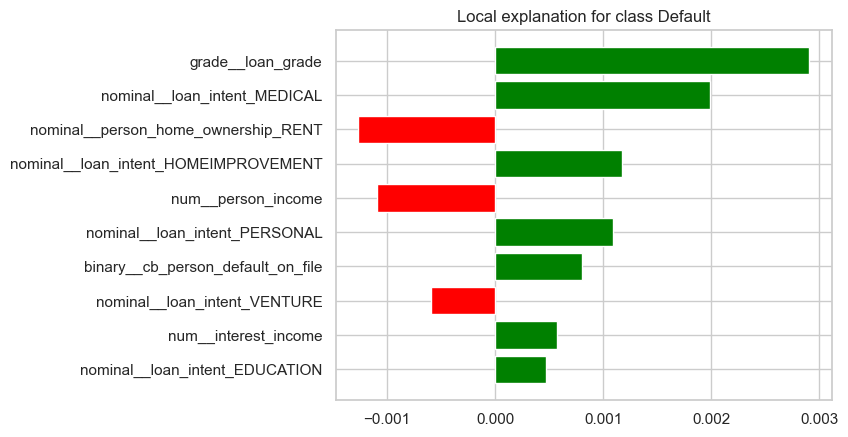

In [46]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML


X_train_fe = feature_engineering(X_train)
X_test_fe = feature_engineering(X_test)

X_train_transformed = prep.transform(X_train_fe)
X_test_transformed = prep.transform(X_test_fe)


feat_names = prep.get_feature_names_out()


classifier = best_model.steps[-1][1]    

explainer = LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feat_names,
    class_names=['Low Risk', 'Default'],
    mode='classification',
    discretize_continuous=False
)


my_custom_client = pd.DataFrame([{
    'person_age': 25,
    'person_income': 50000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 3.0,
    'loan_intent': 'HOMEIMPROVEMENT',
    'loan_grade': 'B',
    'loan_amnt': 10000,
    'loan_int_rate': 11.5,
    'loan_percent_income': 0.25,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 4
}])


my_client_fe = feature_engineering(my_custom_client)
my_client_transformed = prep.transform(my_client_fe)

exp = explainer.explain_instance(
    data_row=my_client_transformed[0],   
    predict_fn=classifier.predict_proba
)


display(HTML(exp.as_html()))
exp.as_pyplot_figure()

მოდელმა კლიენტი შეაფასა როგორც Low Risk (88%),ხოლო გადაუხდელობის შანსი (Default) არის 12%.

loan_grade და სესხის მიზანმა (nominal__loan_intent_MEDICAL) ყველაზე მეტად შეუწყო ხელი ამ პროგნოზის ფორმირებას.

რისკ-ფაქტორები კლიენტის შემოსავალი  და ის ფაქტი, რომ ცხოვრობს ქირით,მოდელმა აღიქვა როგორც რისკის შემცველიფაქტორი, თუმცა საბოლოო ჯამში დადებითმა მაჩვენებლებმა გადაწონა და კლიენტი მაინც დაბალი რისკის კატეგორიაში მოხვდა.

In [47]:
import joblib
joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']